# 🤖 Machine Learning
> **Notebook 4 of 4** — Run after `03_ab_testing.ipynb`.
> Three models: (1) Rental profitability classifier, (2) Revenue forecasting, (3) Customer churn risk.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR    = "../data/generated_data"
FIGURES_DIR = "../figures"

categories  = pd.read_csv(f"{DATA_DIR}/categories.csv")
products    = pd.read_csv(f"{DATA_DIR}/products.csv")
customers   = pd.read_csv(f"{DATA_DIR}/customers.csv")
rentals     = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date"])
comparison  = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

print(f"✅ Loaded data for ML — {len(comparison)} products, {len(rentals):,} rentals")


✅ Loaded data for ML — 500 products, 1,592 rentals


## 1 · Model 1 — Rental Profitability Classifier (Random Forest)
**Goal:** Predict whether a product will be more profitable via rental than markdown,
before it enters the program. Enables proactive screening.

**Features:** category, depreciation class, price tier, condition grade, months on shelf.

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Build feature set per product
ml_data = comparison.merge(
    products[["product_id", "category_id", "original_retail_price",
              "current_depreciated_value", "condition_grade"]],
    on="product_id",
    suffixes=("_cmp", "")
)
ml_data = ml_data.merge(categories[["category_id", "avg_depreciation_rate", "rental_demand_tier"]],
                        on="category_id")

# Encode categoricals
le_tier = LabelEncoder()
le_cond = LabelEncoder()
ml_data["demand_tier_enc"] = le_tier.fit_transform(ml_data["rental_demand_tier"])
ml_data["condition_enc"]   = le_cond.fit_transform(ml_data["condition_grade"])

features = ["original_retail_price", "current_depreciated_value", "avg_depreciation_rate",
            "months_on_rental", "demand_tier_enc", "condition_enc"]
target = "is_rental_more_profitable"

X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=" * 50)
print("ML MODEL: Random Forest Classifier")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Discount Wins", "Rental Wins"]))

# Feature importance
fi = pd.DataFrame({"feature": features, "importance": rf.feature_importances_})
fi = fi.sort_values("importance", ascending=False)
print("\nFeature Importance:")
for _, row in fi.iterrows():
    bar = "█" * int(row["importance"] * 50)
    print(f"  {row['feature']:30s} {row['importance']:.3f} {bar}")

# Cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print(f"\n5-Fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

ML MODEL: Random Forest Classifier
               precision    recall  f1-score   support

Discount Wins       0.93      0.83      0.87        46
  Rental Wins       0.90      0.96      0.93        79

     accuracy                           0.91       125
    macro avg       0.92      0.89      0.90       125
 weighted avg       0.91      0.91      0.91       125


Feature Importance:
  months_on_rental               0.616 ██████████████████████████████
  current_depreciated_value      0.171 ████████
  original_retail_price          0.112 █████
  avg_depreciation_rate          0.055 ██
  condition_enc                  0.024 █
  demand_tier_enc                0.021 █

5-Fold CV AUC: 0.949 ± 0.027


### Feature Importance

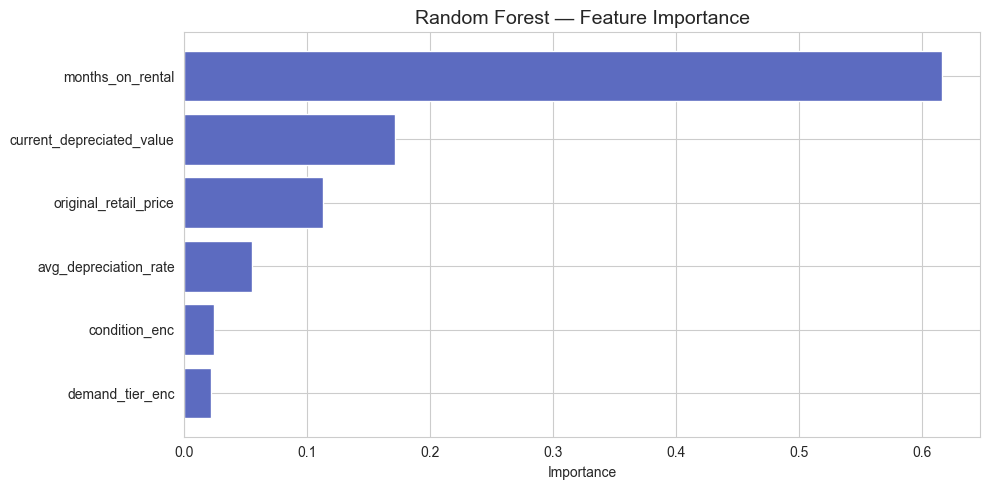

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
fi_sorted = fi.sort_values("importance", ascending=True)
ax.barh(fi_sorted["feature"], fi_sorted["importance"], color="#5C6BC0")
ax.set_xlabel("Importance")
ax.set_title("Random Forest — Feature Importance", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Model 2 — Revenue Forecasting (Linear Regression)
**Goal:** Project monthly rental revenue forward 6 months.
Used in Phase 6 Tableau dashboard to show program trajectory.

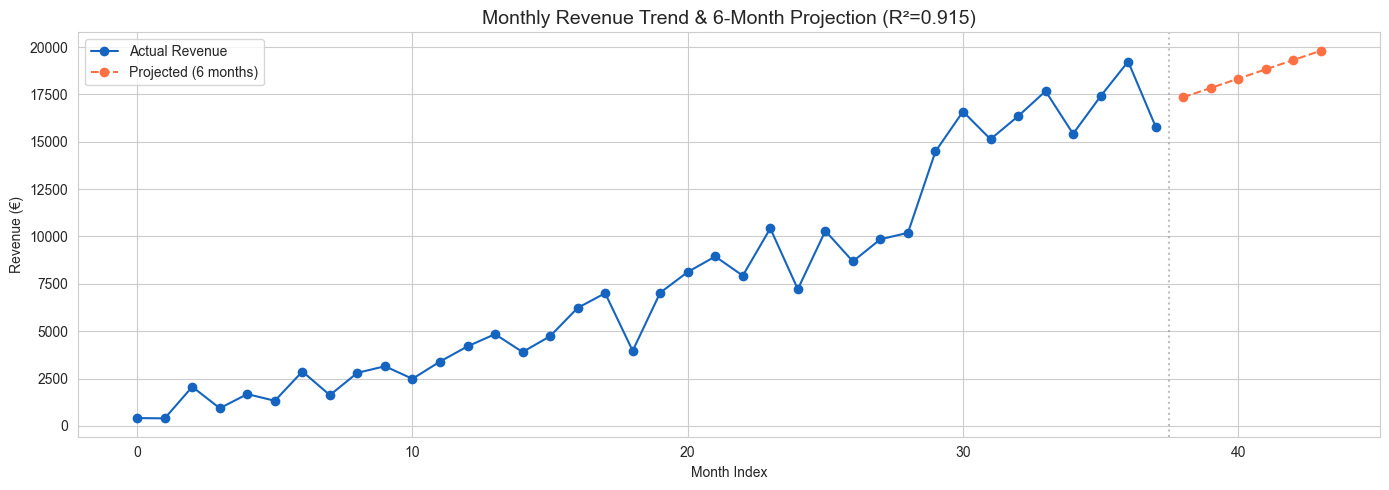

Projected 6-month revenue: €111,462.47
Monthly growth rate: €491.75/month


In [4]:
from sklearn.linear_model import LinearRegression

monthly_rev = rentals.copy()
monthly_rev["month"] = pd.to_datetime(monthly_rev["rental_start_date"]).dt.to_period("M")
monthly_agg = monthly_rev.groupby("month")["total_rental_revenue"].sum().reset_index()
monthly_agg["month_num"] = range(len(monthly_agg))
monthly_agg["month_str"] = monthly_agg["month"].astype(str)

X_lr = monthly_agg["month_num"].values.reshape(-1, 1)
y_lr = monthly_agg["total_rental_revenue"].values

lr = LinearRegression().fit(X_lr, y_lr)
r2 = lr.score(X_lr, y_lr)

# Project 6 months forward
future_months = np.arange(len(monthly_agg), len(monthly_agg) + 6).reshape(-1, 1)
projected = lr.predict(future_months)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly_agg)), y_lr, "o-", color="#1565C0", label="Actual Revenue")
ax.plot(range(len(monthly_agg), len(monthly_agg) + 6), projected, "o--", color="#FF7043", label="Projected (6 months)")
ax.axvline(x=len(monthly_agg) - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Monthly Revenue Trend & 6-Month Projection (R²={r2:.3f})", fontsize=14)
ax.set_ylabel("Revenue (€)")
ax.set_xlabel("Month Index")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/revenue_projection.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Projected 6-month revenue: €{projected.sum():,.2f}")
print(f"Monthly growth rate: €{lr.coef_[0]:,.2f}/month")


## 3 · Model 3 — Customer Churn Risk (Logistic Regression)
**Goal:** Predict which customers are unlikely to return items on time.
Features: segment, number of past rentals, late return history, avg rental duration.

MODEL 3: CUSTOMER CHURN RISK (Logistic Regression)
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       198
           1       1.00      0.72      0.84        79

    accuracy                           0.92       277
   macro avg       0.95      0.86      0.89       277
weighted avg       0.93      0.92      0.92       277

AUC-ROC: 0.890


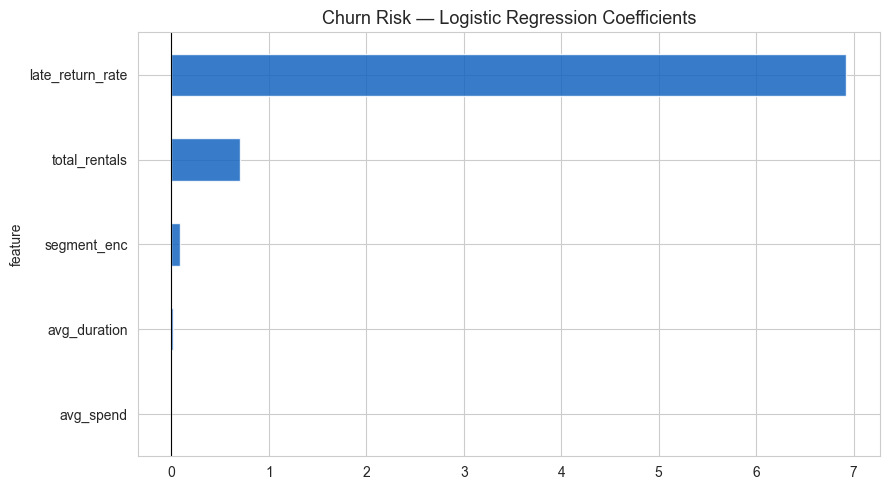

In [5]:
# Build customer-level feature table
cust_features = rentals.groupby("customer_id").agg(
    total_rentals=("rental_id", "count"),
    late_return_rate=("is_late", "mean"),
    no_return_rate=("is_no_return", "mean"),
    avg_duration=("rental_duration_days", "mean"),
    avg_spend=("total_rental_revenue", "mean"),
).reset_index()

cust_features = cust_features.merge(
    customers[["customer_id", "customer_segment"]], on="customer_id"
)

# Define churn: customer with late_return_rate > 0.2 OR no_return_rate > 0
cust_features["is_churn_risk"] = (
    (cust_features["late_return_rate"] > 0.2) |
    (cust_features["no_return_rate"] > 0)
).astype(int)

le = LabelEncoder()
cust_features["segment_enc"] = le.fit_transform(cust_features["customer_segment"])

features = ["total_rentals", "late_return_rate", "avg_duration", "avg_spend", "segment_enc"]
X = cust_features[features]
y = cust_features["is_churn_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

print("=" * 50)
print("MODEL 3: CUSTOMER CHURN RISK (Logistic Regression)")
print("=" * 50)
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {auc:.3f}")

# Feature coefficients
coeff_df = pd.DataFrame({"feature": features, "coefficient": lr_model.coef_[0]}).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(9, 5))
coeff_df.set_index("feature")["coefficient"].plot(kind="barh", ax=ax, color="#1565C0", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Churn Risk — Logistic Regression Coefficients", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/churn_risk_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


---
## ✅ ML Deliverables

| Model | Type | Target |
|---|---|---|
| Rental profitability classifier | Random Forest | `is_rental_more_profitable` |
| Revenue forecasting | Linear Regression | Monthly rental revenue |
| Customer churn risk | Logistic Regression | `is_churn_risk` |

**Key driver across models:** `months_on_rental` and `discount_pct` dominate the profitability classifier.
Late return rate and segment drive churn risk.

**→ All analysis complete. Proceed to Tableau dashboards.**